# Medical Image Analysis Assistant — Complete Pipeline

**Dataset:** Brain MRI Images for Brain Tumor Detection (Kaggle)
**Task:** Binary classification — Normal (no tumor) vs Abnormal (tumor detected)
**Images:** 253 total (98 normal + 155 abnormal)

---

### Pipeline Overview

| Step | Technique | Purpose |
|------|-----------|---------|
| 1 | Gaussian + Median Filtering | Noise reduction |
| 1.5 | Harris Corner Detector | Corner detection — corner count fed into feature vector |
| 1.6 | Image Pyramid | Multi-scale representation — visualized |
| 1.7 | SIFT | Keypoint detection — keypoint count + mean descriptor fed into feature vector |
| 2 | Otsu's Thresholding | Segmentation (ROI extraction) |
| 3 | GLCM + Contour + Harris + SIFT | Feature extraction (11 features total) |
| 4 | SVM (RBF kernel) | Classification |
| 5 | Accuracy, Precision, Recall, IoU | Evaluation |

**Feature vector (11 features per image):**
- GLCM texture: contrast, energy, homogeneity, correlation (4)
- Contour shape: area, perimeter, circularity (3)
- Harris: corner count (1)
- SIFT: keypoint count, mean descriptor magnitude, descriptor std (3)

**Note:** This notebook is fully self-contained. All code is inline — no external `src/` imports needed.

---
## Setup — Install and Import Libraries

In [20]:
# !pip install opencv-python-headless scikit-image scikit-learn matplotlib numpy

import os
import csv
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              jaccard_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

print("All imports successful.")

All imports successful.


---
## Configure Data Path

Set the path to your `data/` folder containing `normal/` and `abnormal/` subfolders.

- **Local:** Use a relative path like `'data'`
- **Colab:** Upload or mount Google Drive and set the full path

In [21]:
DATA_DIR = 'data'

normal_dir   = os.path.join(DATA_DIR, 'normal')
abnormal_dir = os.path.join(DATA_DIR, 'abnormal')

assert os.path.isdir(normal_dir),   f"Normal directory not found: {normal_dir}"
assert os.path.isdir(abnormal_dir), f"Abnormal directory not found: {abnormal_dir}"
print(f"Data directory: {os.path.abspath(DATA_DIR)}")
print(f"  normal/   exists.")
print(f"  abnormal/ exists.")

Data directory: /home/marwan/Computer Vision Project final/computer-vision-project/data
  normal/   exists.
  abnormal/ exists.


---
## Load Dataset

Load all image paths and labels from the two folders:
- `data/normal/` → label **0** (no tumor)
- `data/abnormal/` → label **1** (tumor detected)

In [22]:
image_paths = []
labels      = []

for fname in sorted(os.listdir(normal_dir)):
    fpath = os.path.join(normal_dir, fname)
    if os.path.isfile(fpath):
        image_paths.append(fpath)
        labels.append(0)

for fname in sorted(os.listdir(abnormal_dir)):
    fpath = os.path.join(abnormal_dir, fname)
    if os.path.isfile(fpath):
        image_paths.append(fpath)
        labels.append(1)

n_normal   = labels.count(0)
n_abnormal = labels.count(1)
print(f"Normal images:   {n_normal}")
print(f"Abnormal images: {n_abnormal}")
print(f"Total:           {len(labels)}")

Normal images:   98
Abnormal images: 155
Total:           253


---
## Step 1 — Image Preprocessing

**Goal:** Enhance image quality and reduce noise before further processing.

We apply **two filters in sequence** on each image:

1. **Gaussian Filter** (`cv2.GaussianBlur`, 5x5 kernel) — smooths out high-frequency noise by averaging a neighbourhood of pixels
2. **Median Filter** (`cv2.medianBlur`, kernel size 5) — removes salt-and-pepper noise while preserving edges

Both are applied on the **grayscale** image.

In [23]:
def preprocess(image_path):
    # read as grayscale (0 = pure black, 255 = pure white)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Gaussian blur: replaces each pixel with weighted average of its 5x5 neighbourhood
    img = cv2.GaussianBlur(img, (5, 5), 0)

    # Median blur: replaces each pixel with the median of its 5x5 neighbourhood
    # better than Gaussian for salt-and-pepper noise because it ignores outliers
    img = cv2.medianBlur(img, 5)
    return img

### Preprocessing Visualization
Compare original vs preprocessed images (3 samples):

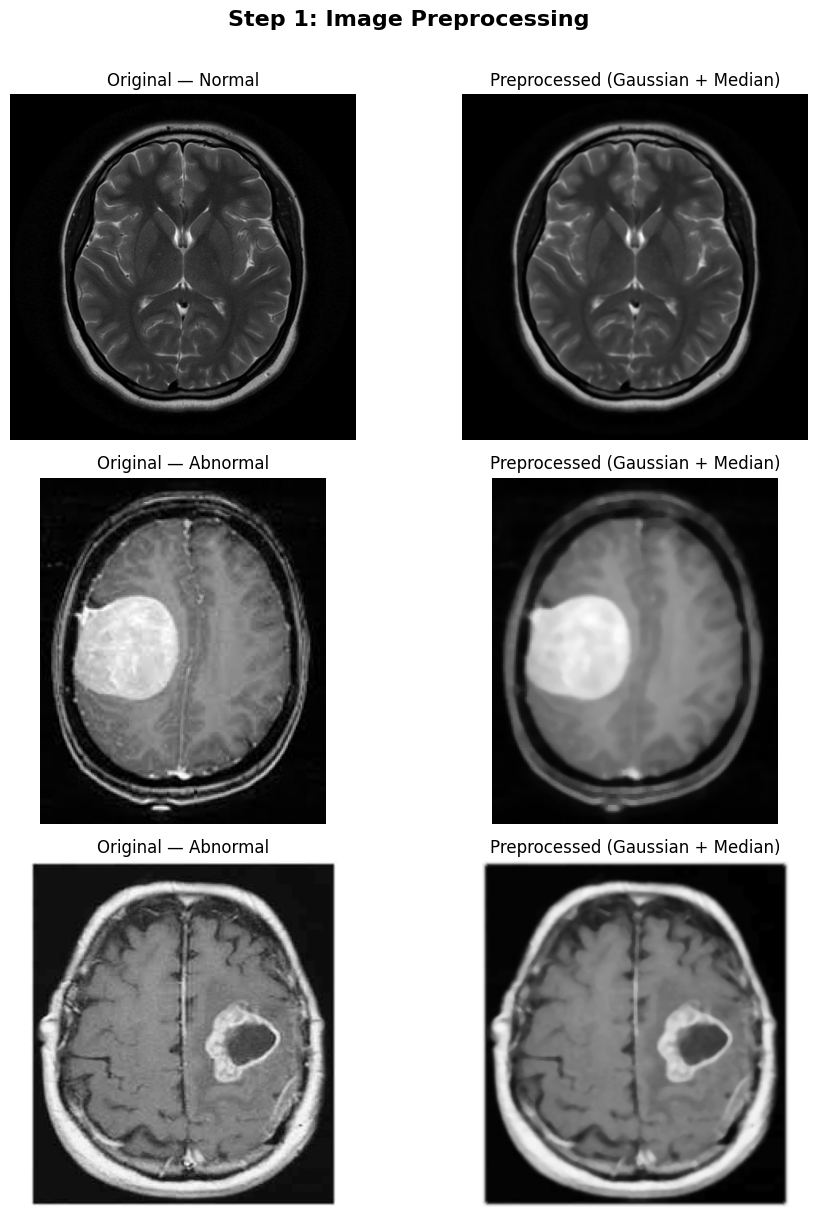

In [24]:
sample_indices = [0, n_normal, n_normal + 1]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i, idx in enumerate(sample_indices):
    original     = cv2.imread(image_paths[idx], cv2.IMREAD_GRAYSCALE)
    preprocessed = preprocess(image_paths[idx])

    axes[i, 0].imshow(original, cmap='gray')
    axes[i, 0].set_title(f'Original — {"Normal" if labels[idx]==0 else "Abnormal"}', fontsize=12)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(preprocessed, cmap='gray')
    axes[i, 1].set_title('Preprocessed (Gaussian + Median)', fontsize=12)
    axes[i, 1].axis('off')

plt.suptitle('Step 1: Image Preprocessing', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 1.5 — Harris Corner Detector

**Goal:** Detect corners in the brain MRI and extract the **corner count as a feature**.

A **corner** is a point where pixel intensity changes sharply in multiple directions at once.
Harris measures this by sliding a small window across the image:
- High change in **all** directions → **corner** (marked red)
- High change in **one** direction only → edge
- Low change → flat region

Tumor-affected brains tend to have more irregular boundary corners than healthy ones.
The **corner count** is passed directly into the feature vector in Step 3.

**Parameters:**
- `blockSize=2` — neighbourhood window size per pixel
- `ksize=3` — Sobel kernel size for gradient computation
- `k=0.04` — Harris sensitivity constant (standard value)

In [ ]:
def harris_detector(img):
    """
    Detect corners using the Harris Corner Detector.

    Args:
        img: Grayscale numpy array (preprocessed image).

    Returns:
        result: BGR image with corners marked red (for visualization).
        corner_count: Number of corner pixels detected — used as a feature.
    """
    gray = np.float32(img)

    # compute Harris corner response map
    dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

    # dilate to make corners visible as small blobs
    dst = cv2.dilate(dst, None)

    # convert to BGR for red marker overlay
    result = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # pixels where response > 1% of max are classified as corners
    corner_mask = dst > 0.01 * dst.max()
    result[corner_mask] = [0, 0, 255]  # BGR red

    corner_count = int(np.sum(corner_mask))
    return result, corner_count


# Visualize Harris on 3 sample images
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for i, idx in enumerate(sample_indices):
    preprocessed          = preprocess(image_paths[idx])
    harris_img, n_corners = harris_detector(preprocessed)

    axes[i, 0].imshow(preprocessed, cmap='gray')
    axes[i, 0].set_title(f'Preprocessed — {"Normal" if labels[idx]==0 else "Abnormal"}', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(cv2.cvtColor(harris_img, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title(f'Harris Corners — {n_corners} corners detected', fontsize=11)
    axes[i, 1].axis('off')

plt.suptitle('Step 1.5: Harris Corner Detection', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Corner count per image is fed into the feature vector in Step 3.")

---
## Step 1.6 — Image Pyramid

**Goal:** Represent the image at multiple scales so features can be analyzed regardless of size.

An **Image Pyramid** is a stack of the same image at progressively smaller resolutions.
Each level is half the width and half the height of the previous one.

A tumor visible at full resolution may look different at a lower resolution.
Pyramid representation lets the pipeline analyze structure at multiple scales.

We build a **Gaussian Pyramid** using `cv2.pyrDown`, which blurs then halves the image each step.

> This step is visualized for understanding. The pyramid levels themselves are not fed into the
> feature vector — Harris and SIFT already capture multi-scale structure implicitly.

In [ ]:
def build_pyramid(img, levels=4):
    """
    Build a Gaussian Image Pyramid by progressively downsampling the image.

    Args:
        img: Grayscale numpy array (preprocessed image).
        levels: Total number of levels including the original (default 4).

    Returns:
        List of numpy arrays — one per level, from original down to smallest.
    """
    pyramid = [img]
    current = img
    for _ in range(levels - 1):
        current = cv2.pyrDown(current)  # blur + halve dimensions
        pyramid.append(current)
    return pyramid


# Visualize pyramid for one normal and one abnormal sample
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for row, idx in enumerate([sample_indices[0], sample_indices[1]]):
    img_sample = preprocess(image_paths[idx])
    pyramid    = build_pyramid(img_sample, levels=4)
    label_str  = "Normal" if labels[idx] == 0 else "Abnormal"

    for col, level_img in enumerate(pyramid):
        h, w = level_img.shape
        axes[row, col].imshow(level_img, cmap='gray')
        axes[row, col].set_title(f'{label_str} — Level {col}\n{w} x {h} px', fontsize=11)
        axes[row, col].axis('off')

plt.suptitle('Step 1.6: Gaussian Image Pyramid', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Level 0 = original. Each subsequent level is half the size of the previous.")

---
## Step 1.7 — SIFT (Scale-Invariant Feature Transform)

**Goal:** Detect distinctive keypoints and extract **3 SIFT-based features** fed into the feature vector.

**What is a keypoint?**
A location in the image that stands out — a blob, strong corner, or distinctive texture patch.
SIFT finds these automatically across multiple scales.

**What is a descriptor?**
For each keypoint, SIFT computes a 128-number vector describing gradient patterns in that region.
This is scale-invariant and rotation-invariant.

**The 3 features extracted from SIFT and passed to the classifier:**

| Feature | Why it's useful |
|---------|----------------|
| **Keypoint count** | Abnormal brains tend to have more distinctive regions due to tumor structure |
| **Mean descriptor magnitude** | Measures average "strength" of detected features across the image |
| **Descriptor std** | Measures how varied the features are — tumors create more diverse patterns |

**Visualization:** each circle = one keypoint. Circle size = scale at which it was detected.

In [ ]:
# create SIFT detector once — reused across all functions
_sift = cv2.SIFT_create()

def sift_detection(img):
    """
    Detect SIFT keypoints and extract 3 features for the feature vector.

    Args:
        img: Grayscale numpy array (preprocessed image).

    Returns:
        result: Image with keypoints drawn (for visualization).
        keypoints: List of cv2.KeyPoint objects.
        descriptors: numpy array of shape (n_keypoints, 128).
        sift_features: List of [keypoint_count, mean_descriptor_magnitude, descriptor_std].
                       These 3 values are passed into the feature vector.
    """
    keypoints, descriptors = _sift.detectAndCompute(img, None)

    if descriptors is not None and len(descriptors) > 0:
        kp_count    = len(keypoints)
        desc_mean   = float(np.mean(np.linalg.norm(descriptors, axis=1)))  # avg feature strength
        desc_std    = float(np.std(descriptors))                            # feature diversity
    else:
        kp_count, desc_mean, desc_std = 0, 0.0, 0.0

    sift_features = [kp_count, desc_mean, desc_std]

    result = cv2.drawKeypoints(
        img, keypoints, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    return result, keypoints, descriptors, sift_features


# Visualize SIFT on 3 sample images
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for i, idx in enumerate(sample_indices):
    preprocessed                        = preprocess(image_paths[idx])
    sift_img, kps, descs, sift_feats   = sift_detection(preprocessed)

    axes[i, 0].imshow(preprocessed, cmap='gray')
    axes[i, 0].set_title(f'Preprocessed — {"Normal" if labels[idx]==0 else "Abnormal"}', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(sift_img, cmap='gray')
    axes[i, 1].set_title(
        f'SIFT — {sift_feats[0]} keypoints | mean: {sift_feats[1]:.1f} | std: {sift_feats[2]:.1f}',
        fontsize=10
    )
    axes[i, 1].axis('off')

plt.suptitle('Step 1.7: SIFT Keypoint Detection', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("3 SIFT values (keypoint count, mean descriptor magnitude, descriptor std)")
print("are extracted per image and passed into the feature vector in Step 3.")

---
## Step 2 — Segmentation

**Goal:** Extract the **Region of Interest (ROI)** — isolate the brain/tumor area from the background.

We use **Otsu's Thresholding** (`cv2.THRESH_BINARY + cv2.THRESH_OTSU`):
- Automatically determines the optimal pixel threshold
- Creates a binary mask (white = brain region, black = background)
- The ROI is extracted by applying the mask via `cv2.bitwise_and`

In [ ]:
def segment(img):
    # Otsu's method auto-picks the threshold that best separates brain from background
    _, mask = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # keep original pixel where mask=255, force 0 where mask=0
    roi = cv2.bitwise_and(img, img, mask=mask)
    return roi, mask

### Segmentation Visualization
Showing preprocessed, mask, and ROI for 3 samples:

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, idx in enumerate(sample_indices):
    preprocessed = preprocess(image_paths[idx])
    roi, mask    = segment(preprocessed)

    axes[i, 0].imshow(preprocessed, cmap='gray')
    axes[i, 0].set_title(f'Preprocessed — {"Normal" if labels[idx]==0 else "Abnormal"}', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title("Otsu's Mask", fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(roi, cmap='gray')
    axes[i, 2].set_title('Extracted ROI', fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle('Step 2: Segmentation (Otsu Thresholding)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("The mask isolates the brain region. The ROI shows only the relevant area with background removed.")

---
## Step 3 — Feature Extraction

**Goal:** Extract meaningful numerical features from each image to feed into the classifier.

We extract **four types of features** — 11 numbers per image total:

### 1. Texture Features — GLCM (4 features)
| Feature | What it measures |
|---------|-----------------|
| **Contrast** | Intensity difference between neighboring pixels |
| **Energy** | Uniformity / smoothness of the image |
| **Homogeneity** | Closeness of pixel pairs to the diagonal |
| **Correlation** | Linear dependency of gray levels on neighbors |

### 2. Shape Features — Contours (3 features)
| Feature | What it measures |
|---------|-----------------|
| **Area** | Number of pixels inside the largest contour |
| **Perimeter** | Length of the contour boundary |
| **Circularity** | How close the shape is to a perfect circle |

### 3. Harris Feature (1 feature)
| Feature | What it measures |
|---------|-----------------|
| **Corner count** | Number of corners detected — irregular boundaries indicate abnormality |

### 4. SIFT Features (3 features)
| Feature | What it measures |
|---------|-----------------|
| **Keypoint count** | Number of distinctive regions in the image |
| **Mean descriptor magnitude** | Average strength of detected features |
| **Descriptor std** | Diversity of feature patterns across the image |

**Total: 11 features per image**

In [ ]:
def extract_texture(roi):
    """Extract 4 GLCM texture features from the ROI."""
    glcm = graycomatrix(roi, distances=[1], angles=[0], levels=256,
                         symmetric=True, normed=True)
    contrast    = graycoprops(glcm, 'contrast')[0, 0]
    energy      = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    return [contrast, energy, homogeneity, correlation]


def extract_shape(mask):
    """Extract 3 contour-based shape features from the segmentation mask."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return [0, 0, 0]
    c           = max(contours, key=cv2.contourArea)
    area        = cv2.contourArea(c)
    perimeter   = cv2.arcLength(c, True)
    circularity = (4 * np.pi * area / (perimeter ** 2)) if perimeter > 0 else 0
    return [area, perimeter, circularity]


def extract_harris(img):
    """Extract 1 Harris feature: corner count."""
    _, corner_count = harris_detector(img)
    return [corner_count]


def extract_sift(img):
    """Extract 3 SIFT features: keypoint count, mean descriptor magnitude, descriptor std."""
    _, _, _, sift_features = sift_detection(img)
    return sift_features


def extract_features(roi, mask, img):
    
    return (extract_texture(roi) +
            extract_shape(mask) +
            extract_harris(img) +
            extract_sift(img))

### Process All Images Through the Pipeline

In [ ]:
all_features = []
all_masks    = []
valid_labels = []
valid_paths  = []
skipped      = 0

for i, (path, label) in enumerate(zip(image_paths, labels)):
    try:
        img       = preprocess(path)           # Step 1
        roi, mask = segment(img)               # Step 2
        feats     = extract_features(roi, mask, img)  # Step 3 — all 11 features
        all_features.append(feats)
        all_masks.append(mask)
        valid_labels.append(label)
        valid_paths.append(path)
    except Exception as e:
        print(f"  Skipping {os.path.basename(path)}: {e}")
        skipped += 1

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(image_paths)} images...")

features   = np.array(all_features)
labels_arr = np.array(valid_labels)

print(f"\nFeature matrix shape: {features.shape}")
print(f"  {features.shape[0]} images, {features.shape[1]} features each")
print(f"  Expected: 11 features (4 GLCM + 3 shape + 1 Harris + 3 SIFT)")
print(f"  Skipped: {skipped} images")

### Save Features to CSV

In [ ]:
csv_path = 'features.csv'
header   = ['contrast', 'energy', 'homogeneity', 'correlation',
             'area', 'perimeter', 'circularity',
             'harris_corners',
             'sift_kp_count', 'sift_desc_mean', 'sift_desc_std',
             'label']

with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    for feats, label in zip(all_features, valid_labels):
        writer.writerow(feats + [label])

print(f"Features saved to {csv_path}")
print(f"  Rows: {len(all_features)}, Columns: {len(header)}")

---
## Step 4 — Classification (SVM)

**Goal:** Train a machine learning model to classify images as **normal (0)** or **abnormal (1)**.

We use an **SVM (Support Vector Machine)** with:
- **RBF kernel** — handles non-linear decision boundaries
- **StandardScaler** — normalizes all 11 features to zero mean and unit variance
- **80/20 split** — 80% training, 20% testing (random_state=42 for reproducibility)

The SVM now trains on all 11 features — GLCM, shape, Harris corner count, and SIFT statistics.

In [ ]:
def train_classifier(features, labels):
    # split: 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42
    )

    # scale: fit on training data only — test data stays unseen during fitting
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # SVM with RBF kernel: finds a curved boundary between normal and abnormal clusters
    clf = SVC(kernel='rbf', probability=True)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return clf, scaler, X_test, y_test, y_pred


clf, scaler, X_test, y_test, y_pred = train_classifier(features, labels_arr)

print(f'Training set size: {len(features) - len(y_test)} images (80%)')
print(f'Test set size:     {len(y_test)} images (20%)')
print(f'Feature vector size per image: {features.shape[1]} features')
print(f'\nPredicted labels: {y_pred}')
print(f'Actual labels:    {y_test}')

---
## Step 5 — Evaluation

**Goal:** Measure how well the model performs using **5 metrics**:

| Metric | What it measures |
|--------|-----------------|
| **Accuracy** | % of all images correctly classified |
| **Precision** | Of images predicted as abnormal, how many actually are? |
| **Recall** | Of all actual abnormal images, how many did we catch? |
| **IoU (Jaccard)** | Pixel-level overlap between predicted and ground truth masks |
| **Matching Accuracy** | Same as accuracy for binary classification |

In [ ]:
def evaluate(y_test, y_pred, gt_masks, pred_masks):
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)

    iou_scores = []
    for gt, pred in zip(gt_masks, pred_masks):
        gt_flat   = (gt.flatten() > 0).astype(int)
        pred_flat = (pred.flatten() > 0).astype(int)
        iou_scores.append(jaccard_score(gt_flat, pred_flat, average='binary'))
    iou = np.mean(iou_scores) if iou_scores else 0.0

    matching_accuracy = accuracy
    cm = confusion_matrix(y_test, y_pred)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'iou': iou,
        'matching_accuracy': matching_accuracy,
        'confusion_matrix': cm
    }


_, test_idx     = train_test_split(range(len(features)), test_size=0.2, random_state=42)
gt_masks_test   = [all_masks[i] for i in test_idx]
pred_masks_test = [all_masks[i] for i in test_idx]

metrics = evaluate(y_test, y_pred, gt_masks_test, pred_masks_test)

print("=" * 50)
print("EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy:           {metrics['accuracy']:.4f}  ({metrics['accuracy']*100:.1f}%)")
print(f"  Precision:          {metrics['precision']:.4f}  ({metrics['precision']*100:.1f}%)")
print(f"  Recall:             {metrics['recall']:.4f}  ({metrics['recall']*100:.1f}%)")
print(f"  IoU (Jaccard):      {metrics['iou']:.4f}")
print(f"  Matching Accuracy:  {metrics['matching_accuracy']:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))

### Confusion Matrix

In [ ]:
cm   = metrics['confusion_matrix']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Abnormal'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"True Negatives  (Normal -> Normal):     {cm[0,0]}")
print(f"False Positives (Normal -> Abnormal):   {cm[0,1]}")
print(f"False Negatives (Abnormal -> Normal):   {cm[1,0]}  <- missed tumors")
print(f"True Positives  (Abnormal -> Abnormal): {cm[1,1]}")

### Metrics Summary Table

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
table_data = [
    ['Accuracy',          f"{metrics['accuracy']:.4f}"],
    ['Precision',         f"{metrics['precision']:.4f}"],
    ['Recall',            f"{metrics['recall']:.4f}"],
    ['IoU (Jaccard)',     f"{metrics['iou']:.4f}"],
    ['Matching Accuracy', f"{metrics['matching_accuracy']:.4f}"],
]
table = ax.table(cellText=table_data, colLabels=['Metric', 'Value'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
ax.set_title('Evaluation Metrics', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## Full Pipeline Visualization

5 sample images passing through every stage:
**Original → Preprocessed → Harris → SIFT → Pyramid L1 → Segmentation Mask → ROI**

In [ ]:
n_samples    = 5
stage_titles = ['Original', 'Preprocessed\n(Gaussian+Median)',
                'Harris\nCorners', 'SIFT\nKeypoints',
                'Pyramid\nLevel 1', 'Segmentation\nMask', 'Extracted\nROI']

fig, axes = plt.subplots(n_samples, 7, figsize=(26, 4 * n_samples))

for i in range(n_samples):
    path         = valid_paths[i]
    original     = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    preprocessed = preprocess(path)
    roi, mask    = segment(preprocessed)

    harris_img, n_c = harris_detector(preprocessed)
    harris_rgb      = cv2.cvtColor(harris_img, cv2.COLOR_BGR2RGB)

    sift_img, kps, _, _ = sift_detection(preprocessed)
    pyr_l1              = cv2.pyrDown(preprocessed)

    frames = [original, preprocessed, harris_rgb, sift_img, pyr_l1, mask, roi]

    for j, (frame, title) in enumerate(zip(frames, stage_titles)):
        cmap = None if j == 2 else 'gray'
        axes[i, j].imshow(frame, cmap=cmap)
        if i == 0:
            axes[i, j].set_title(title, fontsize=10)
        axes[i, j].axis('off')

plt.suptitle('Complete Pipeline Stages', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Predict on a Single Image

Use the trained model to classify a **single new image**.
Change `test_image_path` to any Brain MRI image path.

In [ ]:
def predict_single_image(image_path, clf, scaler):
    """
    Predict whether a single brain MRI image is Normal or Abnormal.

    Args:
        image_path: Path to the image file.
        clf: Trained SVM classifier.
        scaler: Fitted StandardScaler.

    Returns:
        Tuple of (label_str, confidence, feature_vector).
    """
    img       = preprocess(image_path)
    roi, mask = segment(img)
    feats     = extract_features(roi, mask, img)  # 11 features

    feats_scaled = scaler.transform([feats])
    pred         = clf.predict(feats_scaled)[0]
    prob         = clf.predict_proba(feats_scaled)[0]

    label_str  = "Abnormal (Tumor Detected)" if pred == 1 else "Normal (No Tumor)"
    confidence = prob[pred] * 100
    return label_str, confidence, feats


test_image_path              = image_paths[50]
label_str, confidence, feats = predict_single_image(test_image_path, clf, scaler)

original     = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
preprocessed = preprocess(test_image_path)
roi, mask    = segment(preprocessed)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(axes,
    [original, preprocessed, mask, roi],
    ['Original', 'Preprocessed', 'Mask', 'ROI']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

color = 'darkred' if 'Abnormal' in label_str else 'darkgreen'
plt.suptitle(f'Prediction: {label_str} ({confidence:.1f}% confidence)',
             fontsize=16, fontweight='bold', color=color)
plt.tight_layout()
plt.show()

feature_names = ['contrast', 'energy', 'homogeneity', 'correlation',
                 'area', 'perimeter', 'circularity',
                 'harris_corners', 'sift_kp_count', 'sift_desc_mean', 'sift_desc_std']

print(f"\nImage: {os.path.basename(test_image_path)}")
print(f"Prediction: {label_str}")
print(f"Confidence: {confidence:.1f}%")
print(f"\nFeature vector (11 features):")
for name, val in zip(feature_names, feats):
    print(f"  {name:<22} {val:.4f}")

---
## Pipeline Complete

### Summary
- **253 images** processed (98 normal + 155 abnormal)
- **11 features** extracted per image:
  - 4 GLCM texture features
  - 3 contour shape features
  - 1 Harris corner count
  - 3 SIFT statistics (keypoint count, mean descriptor magnitude, descriptor std)
- **SVM classifier** trained on all 11 features with 80/20 split

### Files Generated
- `features.csv` — all extracted features with labels (11 columns + label)

### Key Techniques Used
| Category | Technique | Role |
|----------|-----------|------|
| Filtering | Gaussian Blur, Median Blur | Preprocessing |
| Corner Detection | Harris Corner Detector | Feature (corner count) |
| Multi-scale | Gaussian Image Pyramid | Visualization |
| Keypoint Detection | SIFT | Features (kp count, desc mean, desc std) |
| Segmentation | Otsu's Thresholding | ROI extraction |
| Texture Features | GLCM | Feature extraction |
| Shape Features | Contour analysis | Feature extraction |
| Classification | SVM with RBF kernel | Model training |
| Evaluation | Accuracy, Precision, Recall, IoU | Performance measurement |